# Embeddings II — Images as Vectors

An image is not a row of numbers you can compare directly: two pictures of the same digit can
differ in every single pixel. The trick is to hand the image to a network that has already learned
what visual structure looks like, and read out the vector it produces internally. That vector — the
**embedding** — puts similar images near each other even when their raw pixels do not match.

We never train anything here. We take two networks that were trained on ImageNet, throw away their
classification heads, and use what remains as a fixed feature extractor. Then we ask the same
question as the previous notebook: does cosine similarity in this new space actually separate the
classes?

## Learning objectives

- Use a pretrained CNN with `include_top=False` as a fixed feature extractor
- Explain how global average pooling turns a convolutional feature map into one vector per image
- Apply each model's own `preprocess_input`, and say why the wrong one degrades the embedding
- Compare same-class and different-class cosine similarities to judge an embedding's quality
- Project embeddings to 2-D with PCA and read the resulting scatter
- Compare two encoders on identical image pairs

## Background

Cosine similarity — the measure used throughout — was defined in `U1-1_Embeddings-1_Tabular`:
$\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}$,
running from $-1$ to $1$. That notebook also showed why the space a similarity is computed in
matters more than the similarity formula itself, which is the question we put to each encoder here.

Convolutional networks themselves are covered in Unit 2; here they are used only as black boxes
that map an image to a vector.

## This notebook covers

1. Helper functions reused throughout
2. Loading and preparing the character images
3. Embedding with MobileNetV2
4. Whether those embeddings separate the classes
5. A second encoder, EfficientNetB0
6. The two encoders side by side

**Prerequisites:** `U1-1_Embeddings-1_Tabular` (cosine similarity, and why representation matters)

**Dataset:** `digit_char_dataset.csv` from the shared `Datasets/Images/` folder — 28×28 grayscale
character images, subsampled to 500 each of two classes.

**References:** https://keras.io/api/applications/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Setup and helper functions

Four small utilities that get reused in every section below.

- `to_rgb_uint8` bridges a format mismatch. Our images are 64×64 **grayscale** in $[0,1]$; the
  pretrained networks expect 96×96 **RGB** in $[0,255]$. Copying the single gray channel three
  times is the standard way to feed grayscale data to a color-trained network.
- `make_fixed_pairs` samples a fixed list of index pairs $(i, j)$ once, along with a mask marking
  which pairs share a label. Reusing the *same* pairs for both encoders is what makes the final
  comparison fair — any difference then comes from the embeddings, not from a different draw.
- `pairwise_cos_sims` L2-normalizes each embedding, $\hat{\mathbf{z}} = \mathbf{z}/\lVert\mathbf{z}\rVert$,
  after which the cosine similarity of a pair is just the dot product
  $\hat{\mathbf{z}}_i \cdot \hat{\mathbf{z}}_j$ — much cheaper than forming the full similarity matrix.
- `plot_pair_hist` overlays the same-class and different-class similarity distributions. **The gap
  between those two humps is the figure of merit for the whole notebook.**

The seeds fix the image sample and the sign convention PCA picks, so the notebook reproduces.

In [2]:
import os
import cv2
import tensorflow as tf

# Fixed seeds so the sampled images and the PCA orientation reproduce run to run.
np.random.seed(0)
tf.random.set_seed(0)

IMG_SIZE = 96  # resolution expected by the pretrained CNNs below

# ============================================================
# Helper: convert normalized grayscale images to RGB uint8 at IMG_SIZE
# ============================================================
def to_rgb_uint8(imgs_01):
    """
    Convert (N,H,W,1) or (N,H,W) grayscale images in [0,1] to (N,IMG_SIZE,IMG_SIZE,3)
    RGB float images in [0,255], resized for the pretrained CNNs (which expect 3-channel input).
    """
    imgs_01 = np.squeeze(imgs_01)  # drop channel dim if present -> (N,H,W)
    out = np.zeros((len(imgs_01), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    for i, img in enumerate(imgs_01):
        img_uint8 = (img * 255).astype(np.uint8)
        img_resized = cv2.resize(img_uint8, (IMG_SIZE, IMG_SIZE))
        out[i] = np.stack([img_resized] * 3, axis=-1)
    return out

# ============================================================
# Helper: cosine-similarity histogram on FIXED PAIRS
# ============================================================
def make_fixed_pairs(y, n_pairs=20000, seed=0):
    """
    Make a fixed list of (i,j) index pairs on a label vector y.
    We also return a boolean mask 'same' indicating whether labels match.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    N = len(y)

    # sample i != j uniformly
    i = rng.integers(0, N, size=n_pairs)
    j = rng.integers(0, N, size=n_pairs)
    bad = (i == j)
    while bad.any():
        j[bad] = rng.integers(0, N, size=bad.sum())
        bad = (i == j)

    same = (y[i] == y[j])
    return i, j, same

def pairwise_cos_sims(Z, i, j):
    """
    Compute cosine similarities for pairs (i,j) using embeddings Z.
    """
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)  # L2 normalize
    sims = np.sum(Z[i] * Z[j], axis=1)
    return sims

def plot_pair_hist(sims, same_mask, title="", bins=40):
    sims_same = sims[same_mask]
    sims_diff = sims[~same_mask]

    plt.figure(figsize=(8, 3))
    plt.hist(sims_same, bins=bins, alpha=0.65, label="same class")
    plt.hist(sims_diff, bins=bins, alpha=0.65, label="diff class")
    plt.title(title)
    plt.xlabel("cosine similarity")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2. Load and prepare the images

Two knobs at the top of this cell are meant to be changed, and the results below shift accordingly:

- **`classes`** selects *which* characters to compare. `np.arange(2)` takes classes 0 and 1, but any
  pair — or more than two — can be substituted. The choice matters a great deal: visually distinct
  characters produce cleanly separated similarity humps, while a confusable pair (say `0` and `O`,
  or `1` and `l`) will overlap heavily no matter how good the encoder is. Running an easy pair and a
  hard pair back to back is the fastest way to see that these plots measure the *pairing* as much as
  the embedding.
- **`n_samp_per_class`** sets how many images per class. Equal counts keep the classes balanced, so
  the two histograms below have equal footing.

Each 28×28 image is upsampled to 64×64 and scaled to $[0,1]$, then split 80/20 with `stratify=y` so
both classes keep their proportions in each split.

The grid at the end is a sanity check: look at it and confirm the classes you selected are visually
distinguishable before asking whether a network can tell them apart.

X shape: (1000, 64, 64, 1) y shape: (1000,)
Class counts: {0: 500, 1: 500}


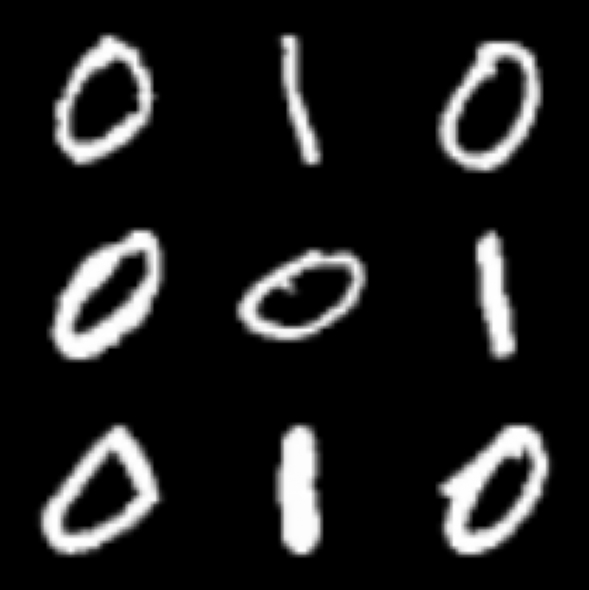

In [3]:
from sklearn.model_selection import train_test_split

data_folder = "C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/Images/"
eng_file = "digit_char_dataset.csv"

df_all = pd.read_csv(os.path.join(data_folder, eng_file))
df_all = df_all.rename(columns={"class": "char"}).astype(int)

classes = np.arange(2)         # digits 0 and 1 (edit as desired)
n_samp_per_class = 500         # per class

dfs = []
for c in classes:
    dfs.append(df_all[df_all["char"] == c].sample(n_samp_per_class, random_state=0))
df_sub = pd.concat(dfs).reset_index(drop=True)

X_28 = df_sub.iloc[:, :-1].to_numpy().reshape(-1, 28, 28).astype(np.float32)
y = df_sub["char"].to_numpy().astype(int)

# resize to 64x64 + normalize
X = np.array([cv2.resize(img, (64, 64)) for img in X_28], dtype=np.float32) / 255.0
X = X[..., None]

print("X shape:", X.shape, "y shape:", y.shape)
print("Class counts:", pd.Series(y).value_counts().sort_index().to_dict())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# show random grid of images (kept)
m, n = 3, 3
fig, axes = plt.subplots(m, n, figsize=(n * 2, m * 2))
for i in range(m):
    for j in range(n):
        idx = np.random.randint(0, len(X_train))
        axes[i, j].imshow(X_train[idx, :, :, 0], cmap="gray")
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

## 3. Embedding with a pretrained MobileNetV2

Three arguments do all the work:

- `include_top=False` discards the 1000-way ImageNet classifier at the end. We do not want
  ImageNet's labels — we want the representation the network built *in order to* produce them.
- `weights="imagenet"` loads the pretrained parameters. Nothing is trained in this notebook, and
  `trainable = False` makes that explicit.
- `pooling="avg"` collapses the final convolutional feature map into a single vector by **global
  average pooling**. If that map has shape $H \times W \times C$, each channel becomes one number:

$$z_c = \frac{1}{HW}\sum_{h=1}^{H}\sum_{w=1}^{W} A_{h,w,c}, \qquad c = 1, \ldots, C$$

So the whole network acts as a fixed function $f : \mathbb{R}^{96 \times 96 \times 3} \to \mathbb{R}^{C}$,
turning each image into a $C$-dimensional vector. That vector is the embedding.

One detail that is easy to get wrong: every model in `keras.applications` ships its **own**
`preprocess_input` encoding the normalization it was trained with. MobileNetV2 expects inputs
scaled to $[-1, 1]$; other families expect ImageNet channel means subtracted. Using the wrong one
silently degrades the embedding — no error, just worse vectors.

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

mobilenet_base = MobileNetV2(
    include_top=False,                     # drop the ImageNet classification head
    weights="imagenet",                    # pretrained weights - no training here
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"                          # global average pooling -> one vector per image
)
mobilenet_base.trainable = False

X_train_mobilenet = mobilenet_preprocess(to_rgb_uint8(X_train))
X_val_mobilenet = mobilenet_preprocess(to_rgb_uint8(X_val))

Z_train_mobilenet = mobilenet_base.predict(X_train_mobilenet, batch_size=128, verbose=0)
Z_val_mobilenet = mobilenet_base.predict(X_val_mobilenet, batch_size=128, verbose=0)

print("MobileNetV2 embedding dimension:", Z_val_mobilenet.shape[1])
print()
print("Example embedding (first validation image):\n", Z_val_mobilenet[0])

MobileNetV2 embedding dimension: 1280

Example embedding (first validation image):
 [0.         0.21769807 0.23893394 ... 0.         0.         0.        ]


## 4. Do these embeddings separate the classes?

Two views of the same question.

**The pair histogram.** Draw 20,000 random pairs of validation images and plot the cosine
similarity of each, colored by whether the pair shares a label. A useful embedding pushes the
same-class hump to the right of the different-class hump. Overlap between the humps is exactly the
region where a downstream classifier will make mistakes.

**The PCA scatter.** The embeddings live in over a thousand dimensions, which we cannot look at.
PCA finds the directions of greatest variance — the leading eigenvectors of the covariance matrix
$\Sigma = \frac{1}{n}\sum_i (\mathbf{z}_i - \bar{\mathbf{z}})(\mathbf{z}_i - \bar{\mathbf{z}})^{\top}$ —
and projects onto the top two, keeping as much spread as any two-dimensional view can.

Read the scatter with care in one respect: PCA maximizes *variance*, not class separation. It is
never told the labels. Classes that look mixed in 2-D may still be cleanly separable in the full
space, so treat the scatter as suggestive and the histogram as the measurement.

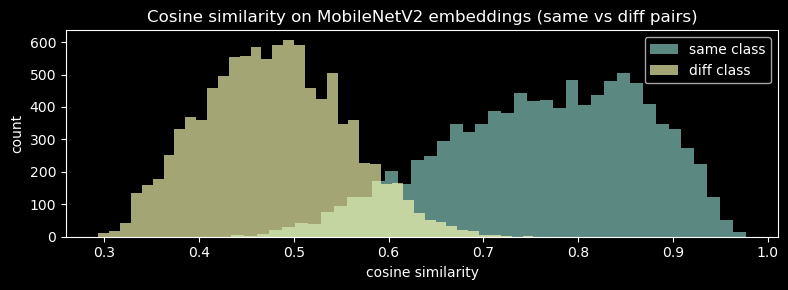

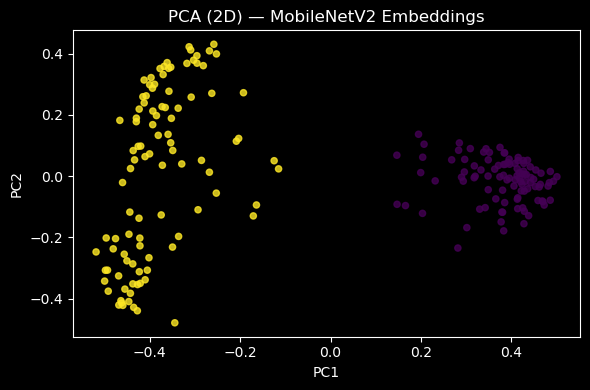

In [5]:
from sklearn.decomposition import PCA

# fixed pairs to reuse later
pair_i, pair_j, pair_same = make_fixed_pairs(y_val, n_pairs=20000, seed=123)

# MobileNetV2 similarity histogram (two colors: same vs diff)
sims_mobilenet = pairwise_cos_sims(Z_val_mobilenet, pair_i, pair_j)
plot_pair_hist(sims_mobilenet, pair_same, title="Cosine similarity on MobileNetV2 embeddings (same vs diff pairs)", bins=40)

# MobileNetV2 PCA (2D)
Zmn = Z_val_mobilenet.astype(float)
Zmn = Zmn / (np.linalg.norm(Zmn, axis=1, keepdims=True) + 1e-9)
pca_mobilenet_2d = PCA(n_components=2, random_state=0).fit_transform(Zmn)

plt.figure(figsize=(6, 4))
plt.scatter(pca_mobilenet_2d[:, 0], pca_mobilenet_2d[:, 1], c=y_val, s=20, alpha=0.8)
plt.title("PCA (2D) — MobileNetV2 Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 5. A second encoder: EfficientNetB0

The same procedure with a different pretrained network. EfficientNetB0 is a later architecture,
trained on the same ImageNet data — so any difference in the results comes from the architecture
and its training recipe, not from the images or our code.

Note that it gets its own `preprocess_input`, imported from `keras.applications.efficientnet`
rather than `mobilenet_v2`.

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

efficientnet_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)
efficientnet_base.trainable = False

# each keras.applications model ships its own preprocess_input convention -
# always call the one matching the model you loaded
X_train_efficientnet = efficientnet_preprocess(to_rgb_uint8(X_train))
X_val_efficientnet = efficientnet_preprocess(to_rgb_uint8(X_val))

Z_train_efficientnet = efficientnet_base.predict(X_train_efficientnet, batch_size=128, verbose=0)
Z_val_efficientnet = efficientnet_base.predict(X_val_efficientnet, batch_size=128, verbose=0)

print("EfficientNetB0 embedding dimension:", Z_val_efficientnet.shape[1])
print()
print("Example embedding (first validation image):\n", Z_val_efficientnet[0])

EfficientNetB0 embedding dimension: 1280

Example embedding (first validation image):
 [-0.22241293 -0.19901007 -0.20112363 ...  0.24171737 -0.12509704
 -0.24004176]


## 6. The two encoders side by side

The comparison is only meaningful because both encoders are scored on the **same** `pair_i` /
`pair_j` list drawn back in section 4. Same images, same pairs, same metric — only the embedding
function differs.

Judge each panel by how far apart the two humps sit and how little they overlap. A wide separation
means a downstream classifier has an easy job in that space; heavy overlap means the encoder has
thrown away the distinction we care about.

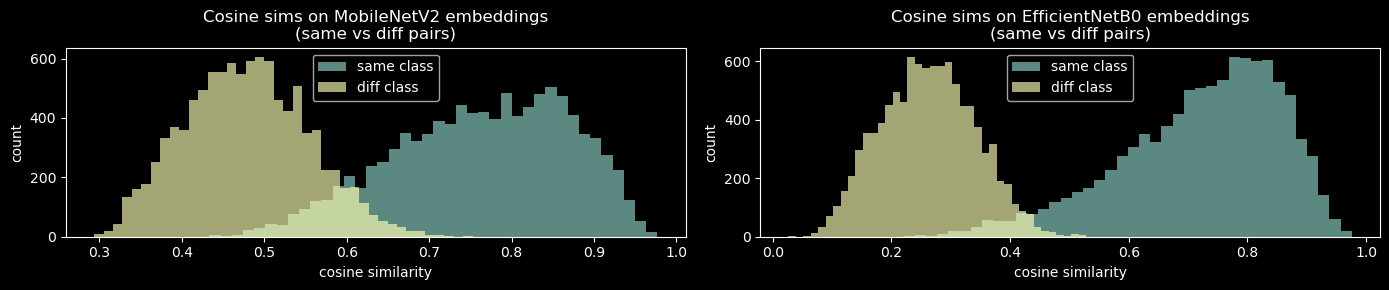

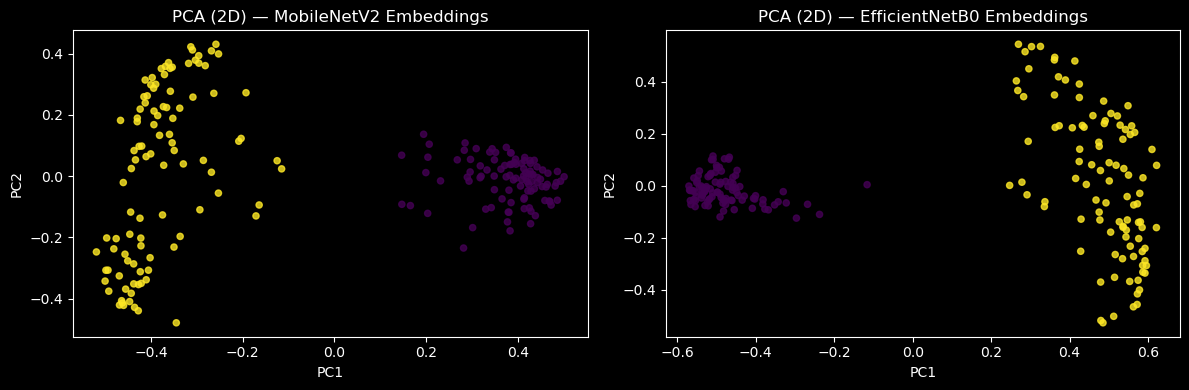

In [7]:
# --- side-by-side PAIR similarity histograms (MobileNetV2 vs EfficientNetB0), using SAME (i,j) pairs ---
sims_efficientnet = pairwise_cos_sims(Z_val_efficientnet, pair_i, pair_j)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# MobileNetV2 hist
axes[0].hist(sims_mobilenet[pair_same], bins=40, alpha=0.65, label="same class")
axes[0].hist(sims_mobilenet[~pair_same], bins=40, alpha=0.65, label="diff class")
axes[0].set_title("Cosine sims on MobileNetV2 embeddings\n(same vs diff pairs)")
axes[0].set_xlabel("cosine similarity")
axes[0].set_ylabel("count")
axes[0].legend()

# EfficientNetB0 hist
axes[1].hist(sims_efficientnet[pair_same], bins=40, alpha=0.65, label="same class")
axes[1].hist(sims_efficientnet[~pair_same], bins=40, alpha=0.65, label="diff class")
axes[1].set_title("Cosine sims on EfficientNetB0 embeddings\n(same vs diff pairs)")
axes[1].set_xlabel("cosine similarity")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- PCA side-by-side (MobileNetV2 vs EfficientNetB0) ---
Zen = Z_val_efficientnet.astype(float)
Zen = Zen / (np.linalg.norm(Zen, axis=1, keepdims=True) + 1e-9)

pca_efficientnet_2d = PCA(n_components=2, random_state=0).fit_transform(Zen)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

axes[0].scatter(pca_mobilenet_2d[:, 0], pca_mobilenet_2d[:, 1], c=y_val, s=20, alpha=0.8)
axes[0].set_title("PCA (2D) — MobileNetV2 Embeddings")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(pca_efficientnet_2d[:, 0], pca_efficientnet_2d[:, 1], c=y_val, s=20, alpha=0.8)
axes[1].set_title("PCA (2D) — EfficientNetB0 Embeddings")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

An encoder winning here is not a claim that it is the better network in general. It is the better
network **for these images**: handwritten characters are far from ImageNet's photographs of animals
and objects, so which pretrained features happen to transfer is partly an accident of the domain
gap. Testing on your own data, as we just did, is the only reliable way to choose.

## 7. Review

- **An embedding is what a pretrained network computes on the way to its answer.** Setting
  `include_top=False` discards the classifier and keeps that representation.
- **`pooling="avg"` makes the output one vector per image**, averaging each channel of the final
  feature map over all spatial positions: $z_c = \frac{1}{HW}\sum_{h,w} A_{h,w,c}$.
- **Nothing is trained here.** A frozen ImageNet network is used as a fixed feature extractor —
  the cheapest useful form of transfer learning.
- **Use the `preprocess_input` that ships with the model you loaded.** A mismatch produces no
  error and a worse embedding.
- **The gap between the same-class and different-class similarity humps measures embedding
  quality**, and the overlap between them is where a downstream classifier will err.
- **PCA is a viewing tool, not a verdict.** It maximizes variance without ever seeing the labels,
  so classes can be separable in the full space while looking mixed in 2-D.
- **Comparing encoders requires holding the pairs fixed**, which is why the pair list is sampled
  once and reused. The better encoder on this data need not be the better encoder generally.